#Executive Summary

The following comparative analysis shows that the Variant group significantly outperformed the Control in the Primary Metric, showing a 21% improvement. Variant also outperformed Control in 2 of the 3 Secondary Metrics, with only a minor decline in the third, and improved on our Guardrail Metric.

Primary Metric:
- Median Time to First Collaboration (Hours): 21.16% **improvement**

Secondary Metric:
- p75 Onboarding Length (Hours): -4.55% **decline**
- p75 Time to First Invite (Hours): 98.35% **improvement**
- % Onboarding Completion: 58.33% **improvement**

Guardrail metric:
- % Onboarding Abandon: 42.86% **improvement**

Our recommendation is to push the Variant test live for all new accounts going forward.

# Comparative Analysis of Onboarding Test

A test was run during the month of Februarywith the following hypothesis:

We believe improving the Onboarding flow will reduce Time to First Collaboration by encouraging new admins to invite teammates and engage with core froduct features sooner.

This anlaysis is a review of the test outcomes, meant to determine if the test successfully improved the intended metrics while staying inside acceptable guardrails. A full breakdown of the test can be found in the Testing Framework. Here are the metrics we will be using in this analysis:

**Primary Metric:**
- Median Time to First Collaboration (Hours)

**Secondary Metrics:**
- p75 Onboarding Length (Hours)
- p75 Time to First Invite (Hours)
- % Onboarding Completion

**Guardrail Metric:**
- % Onboarding Abandon

Variant will go live if:
- **Time to First Collaboration** shows material improvement (target: >10%)
- No meaningful increase in onboarding abandons

This analysis will be done in 4 sections: January Baseline Metrics, February Control Results, February Variant Results, and Baseline v Control v Variant Comparison.

**Section 1: January Baseline Metrics**

  This section will pull from the January exports to re-establish the metrics chosen for the test.

**Section 2: February Control Results**

  This section will use the February exports, filtered to only include those that were not randomly selected for the test experience, to provide timeframe-relevant versions of the metrics chosen for the test.

**Section 3: February Variant Results**

  This section will again use the February exports, but filtered now to only unclude those that were randomly selected for the test experience. This will provide our results of the test independent of context from the Control or Baseline.

**Section 4: Baseline v Control v Variant Comparison**

  At this stage, I will have established the Baseline for our metrics from January, the Control Group's metrics from February, and the Variant Group's metrics from February. I will use this section to compare these 3 metric sets against one another to prove the following:
  - Does the Control Group have similar metrics to the Baseline, or was it markedly different in some way?
  - Did our Variant Group show a material improvement compared to the Control Group?


In [0]:
%python
import pandas as pd
import matplotlib.pyplot as plt

###Section 1: January Baseline Metrics

In [0]:
with baseline_events as (
  select
  org_id,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'first_collaboration_event' then event_timestamp else null end) as first_collaboration_timestamp
  from clean_events_2026_jan
  group by org_id
),

baseline_timing as (
  select
  org_id,
  signup_timestamp,
  first_collaboration_timestamp,
  date_diff(minute, signup_timestamp, first_collaboration_timestamp) as minutes_to_first_collaboration
  from baseline_events
  where signup_timestamp is not null and first_collaboration_timestamp is not null
)

select
  round(percentile_approx(minutes_to_first_collaboration, 0.5) / 60.0,2) as median_hours
from baseline_timing

median_hours
530.78


In [0]:
with baseline_events as (
  select
  org_id,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp
  from clean_events_2026_jan
  group by org_id
),

baseline_timing as (
  select
  org_id,
  onboarding_started_timestamp,
  onboarding_completed_timestamp,
  date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) as minutes_to_complete_onboarding
  from baseline_events
  where onboarding_started_timestamp is not null and onboarding_completed_timestamp is not null
)

select
  round(percentile_approx(minutes_to_complete_onboarding, 0.75) / 60.0,2) as p75_hours
from baseline_timing

p75_hours
2.37


In [0]:
with baseline_events as (
  select
  org_id,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'user_invited' then event_timestamp else null end) as first_invite_timestamp
  from clean_events_2026_jan
  group by org_id
),

baseline_timing as (
  select
  org_id,
  signup_timestamp,
  first_invite_timestamp,
  date_diff(minute, signup_timestamp, first_invite_timestamp) as minutes_to_first_invite
  from baseline_events
  where signup_timestamp is not null and first_invite_timestamp is not null
)

select
  round(percentile_approx(minutes_to_first_invite, 0.75) / 60.0,2) as p75_hours
from baseline_timing

p75_hours
441.80


In [0]:
with baseline_onboarding as (
  select
  org_id,
  max(case when event_type = 'onboarding_completed' then 1 else 0 end) as completed_onboarding,
  max(case when event_type = 'onboarding_abandoned' then 1 else 0 end) as abandoned_onboarding
  from clean_events_2026_jan
  group by org_id
)

select
  round(sum(completed_onboarding) * 100.0 / count(distinct org_id),2) as pct_completed_onboarding,
  round(sum(abandoned_onboarding) * 100.0 / count(distinct org_id),2) as pct_abandoned_onboarding
from baseline_onboarding

pct_completed_onboarding,pct_abandoned_onboarding
38.33,26.67


####Section Review

Primary Metric:
- Median Time to First Collaboration (Hours): **530.78**

Secondary Metrics:
- p75 Onboarding Length (Hours): **2.37**
- p75 Time to First Invite (Hours): **441.80**
- % Onboarding Completion: **38.33**

Guardrail Metric:
- % Onboarding Abandon: **26.67**

###Section 2: February Control Results

In [0]:
with control_events as (
  select
  e.org_id,
  o.onboarding_test,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'first_collaboration_event' then event_timestamp else null end) as first_collaboration_timestamp
  from clean_events_2026_feb e
  left join clean_orgs_2026_feb o 
    on e.org_id = o.org_id
  where o.onboarding_test = false
  group by e.org_id, o.onboarding_test
),

control_timing as (
  select
  org_id,
  signup_timestamp,
  first_collaboration_timestamp,
  date_diff(minute, signup_timestamp, first_collaboration_timestamp) as minutes_to_first_collaboration
  from control_events
  where signup_timestamp is not null and first_collaboration_timestamp is not null
)

select
  round(percentile_approx(minutes_to_first_collaboration, 0.5) / 60.0,2) as median_hours
from control_timing

median_hours
345.85


In [0]:
with control_events as (
  select
  e.org_id,
  o.onboarding_test,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp
  from clean_events_2026_feb e
  left join clean_orgs_2026_feb o 
    on e.org_id = o.org_id
  where o.onboarding_test = false
  group by e.org_id, o.onboarding_test
),

control_timing as (
  select
  org_id,
  onboarding_started_timestamp,
  onboarding_completed_timestamp,
  date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) as minutes_to_complete_onboarding
  from control_events
  where onboarding_started_timestamp is not null and onboarding_completed_timestamp is not null
)

select
  round(percentile_approx(minutes_to_complete_onboarding, 0.75) / 60.0,2) as p75_hours
from control_timing

p75_hours
0.22


In [0]:
with control_events as (
  select
  e.org_id,
  o.onboarding_test,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'user_invited' then event_timestamp else null end) as first_invite_timestamp
  from clean_events_2026_feb e
  left join clean_orgs_2026_feb o 
    on e.org_id = o.org_id
  where o.onboarding_test = false
  group by e.org_id, o.onboarding_test
),

control_timing as (
  select
  org_id,
  signup_timestamp,
  first_invite_timestamp,
  date_diff(minute, signup_timestamp, first_invite_timestamp) as minutes_to_first_invite
  from control_events
  where signup_timestamp is not null and first_invite_timestamp is not null
)

select
  round(percentile_approx(minutes_to_first_invite, 0.75) / 60.0,2) as p75_hours
from control_timing

p75_hours
95.40


In [0]:
with control_onboarding as (
  select
  e.org_id,
  o.onboarding_test,
  max(case when event_type = 'onboarding_completed' then 1 else 0 end) as completed_onboarding,
  max(case when event_type = 'onboarding_abandoned' then 1 else 0 end) as abandoned_onboarding
  from clean_events_2026_feb e
  left join clean_orgs_2026_feb o 
    on e.org_id = o.org_id
  where o.onboarding_test = false
  group by e.org_id, o.onboarding_test
)

select
  round(sum(completed_onboarding) * 100.0 / count(distinct org_id),2) as pct_completed_onboarding,
  round(sum(abandoned_onboarding) * 100.0 / count(distinct org_id),2) as pct_abandoned_onboarding
from control_onboarding

pct_completed_onboarding,pct_abandoned_onboarding
40.00,23.33


####Section Review

Primary Metric:
- Median Time to First Collaboration (Hours): **345.85**

Secondary Metrics:
- p75 Onboarding Length (Hours): **0.22**
- p75 Time to First Invite (Hours): **95.40**
- % Onboarding Completion: **40.00**

Guardrail Metric:
- % Onboarding Abandon: **23.33**

###Section 3: February Variant Results

In [0]:
with variant_events as (
  select
  e.org_id,
  o.onboarding_test,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'first_collaboration_event' then event_timestamp else null end) as first_collaboration_timestamp
  from clean_events_2026_feb e
  left join clean_orgs_2026_feb o 
    on e.org_id = o.org_id
  where o.onboarding_test = true
  group by e.org_id, o.onboarding_test
),

variant_timing as (
  select
  org_id,
  signup_timestamp,
  first_collaboration_timestamp,
  date_diff(minute, signup_timestamp, first_collaboration_timestamp) as minutes_to_first_collaboration
  from variant_events
  where signup_timestamp is not null and first_collaboration_timestamp is not null
)

select
  round(percentile_approx(minutes_to_first_collaboration, 0.5) / 60.0,2) as median_hours
from variant_timing

median_hours
272.67


In [0]:
with variant_events as (
  select
  e.org_id,
  o.onboarding_test,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp
  from clean_events_2026_feb e
  left join clean_orgs_2026_feb o 
    on e.org_id = o.org_id
  where o.onboarding_test = true
  group by e.org_id, o.onboarding_test
),

variant_timing as (
  select
  org_id,
  onboarding_started_timestamp,
  onboarding_completed_timestamp,
  date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) as minutes_to_complete_onboarding
  from variant_events
  where onboarding_started_timestamp is not null and onboarding_completed_timestamp is not null
)

select
  round(percentile_approx(minutes_to_complete_onboarding, 0.75) / 60.0,2) as p75_hours
from variant_timing

p75_hours
0.23


In [0]:
with variant_events as (
  select
  e.org_id,
  o.onboarding_test,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'user_invited' then event_timestamp else null end) as first_invite_timestamp
  from clean_events_2026_feb e
  left join clean_orgs_2026_feb o 
    on e.org_id = o.org_id
  where o.onboarding_test = true
  group by e.org_id, o.onboarding_test
),

variant_timing as (
  select
  org_id,
  signup_timestamp,
  first_invite_timestamp,
  date_diff(minute, signup_timestamp, first_invite_timestamp) as minutes_to_first_invite
  from variant_events
  where signup_timestamp is not null and first_invite_timestamp is not null
)

select
  round(percentile_approx(minutes_to_first_invite, 0.75) / 60.0,2) as p75_hours
from variant_timing

p75_hours
1.57


In [0]:
with variant_onboarding as (
  select
  e.org_id,
  o.onboarding_test,
  max(case when event_type = 'onboarding_completed' then 1 else 0 end) as completed_onboarding,
  max(case when event_type = 'onboarding_abandoned' then 1 else 0 end) as abandoned_onboarding
  from clean_events_2026_feb e
  left join clean_orgs_2026_feb o 
    on e.org_id = o.org_id
  where o.onboarding_test = true
  group by e.org_id, o.onboarding_test
)

select
  round(sum(completed_onboarding) * 100.0 / count(distinct org_id),2) as pct_completed_onboarding,
  round(sum(abandoned_onboarding) * 100.0 / count(distinct org_id),2) as pct_abandoned_onboarding
from variant_onboarding

pct_completed_onboarding,pct_abandoned_onboarding
63.33,13.33


####Section Review

Primary Metric:
- Median Time to First Collaboration (Hours): **272.67**

Secondary Metrics:
- p75 Onboarding Length (Hours): **0.23**
- p75 Time to First Invite (Hours): **1.57**
- % Onboarding Completion: **63.33**

Guardrail Metric:
- % Onboarding Abandon: **13.33**

###Section 4: Baseline v Control v Variant Comparison

Before getting into the comparison, we need to combine tables together so we can run single queries for each metric.

In [0]:
create table merge_clean_orgs_2026_jan as
select
  *,
  false as onboarding_test
from clean_orgs_2026_jan

num_affected_rows,num_inserted_rows


In [0]:
select
  *
from merge_clean_orgs_2026_jan
limit 10

org_id,created_at,created_date,created_time,active_seat_count,owner_user_id,onboarding_status,country,industry,organization_size_band,onboarding_test
org_100005,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,0,usr_200001,abandoned,United States,E-commerce,101-500,false
org_100014,2026-01-01T09:28:57.000Z,2026-01-01,09:28:57,13,usr_200033,completed,United States,Cybersecurity,21-100,false
org_100054,2026-01-02T17:36:35.000Z,2026-01-02,17:36:35,4,usr_200050,completed,United States,Software,2-5,false
org_100057,2026-01-03T01:13:02.000Z,2026-01-03,01:13:02,2,usr_200055,not_started,France,Education,101-500,false
org_100013,2026-01-03T04:44:27.000Z,2026-01-03,04:44:27,9,usr_200057,abandoned,Canada,Software,21-100,false
org_100008,2026-01-03T09:25:33.000Z,2026-01-03,09:25:33,0,usr_200070,abandoned,United States,Cybersecurity,21-100,false
org_100022,2026-01-03T13:45:37.000Z,2026-01-03,13:45:37,4,usr_200076,not_started,Germany,Fintech,2-5,false
org_100029,2026-01-03T17:56:47.000Z,2026-01-03,17:56:47,1,usr_200081,not_started,United States,Government,1,false
org_100049,2026-01-04T11:52:46.000Z,2026-01-04,11:52:46,4,usr_200084,not_started,United States,Software,2-5,false
org_100032,2026-01-04T14:17:11.000Z,2026-01-04,14:17:11,97,usr_200089,abandoned,Japan,Cybersecurity,501+,false


In [0]:
drop table compare_2026_jan_feb

In [0]:
create table compare_2026_jan_feb as

with orgs as (
  select
  org_id,
  'January' as org_created_month,
  onboarding_test
  from merge_clean_orgs_2026_jan

  union all

  select
  org_id,
  'February' as org_created_month,
  onboarding_test
  from clean_orgs_2026_feb
),

events as (
  select 
  *
  from clean_events_2026_jan

  union all

  select 
  *
  from clean_events_2026_feb
)

select
  e.*,
  o.onboarding_test,
  o.org_created_month
from events e
left join orgs o
  on e.org_id = o.org_id

num_affected_rows,num_inserted_rows


In [0]:
select
  *
from compare_2026_jan_feb
limit 10

event_id,event_timestamp,event_date,event_time,event_type,org_id,user_id,event_level,session_id,onboarding_test,org_created_month
evt_300001,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,user_signed_up,org_100005,usr_200001,user,sess_400001,false,January
evt_300002,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,plan_selected,org_100005,usr_200001,org,sess_400001,false,January
evt_300003,2026-01-01T01:10:22.000Z,2026-01-01,01:10:22,user_activated,org_100005,usr_200001,user,sess_400001,false,January
evt_300004,2026-01-01T03:53:22.000Z,2026-01-01,03:53:22,onboarding_started,org_100005,usr_200001,org,sess_400001,false,January
evt_300005,2026-01-01T04:54:22.000Z,2026-01-01,04:54:22,onboarding_abandoned,org_100005,usr_200001,org,sess_400001,false,January
evt_300006,2026-01-18T18:40:08.000Z,2026-01-18,18:40:08,user_invited,org_100005,usr_200001,user,sess_400002,false,January
evt_300007,2026-01-22T16:40:08.000Z,2026-01-22,16:40:08,user_joined,org_100005,usr_200002,user,sess_400003,false,January
evt_300008,2026-01-13T19:31:09.000Z,2026-01-13,19:31:09,user_invited,org_100005,usr_200001,user,sess_400004,false,January
evt_300009,2026-01-13T23:31:09.000Z,2026-01-13,23:31:09,user_joined,org_100005,usr_200003,user,sess_400005,false,January
evt_300010,2026-01-17T08:50:48.000Z,2026-01-17,08:50:48,user_invited,org_100005,usr_200001,user,sess_400006,false,January


In [0]:
alter table compare_2026_jan_feb
add column test_group string;

update compare_2026_jan_feb
set test_group = 
  case 
    when org_created_month = 'January' then 'baseline'
    when onboarding_test = false then 'control'
    when onboarding_test = true then 'variant'
    else 'error' 
  end

num_affected_rows
5770


In [0]:
select
  test_group,
  count(distinct org_id) as orgs
from compare_2026_jan_feb
group by test_group

test_group,orgs
baseline,60
variant,30
control,30


Using our new compare_2026_jan_feb table, we can run individual queries to see each number and compare them against eachother.

#####Median Time to First Collaboration

In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'first_collaboration_event' then event_timestamp else null end) as first_collaboration_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  signup_timestamp,
  first_collaboration_timestamp,
  date_diff(minute, signup_timestamp, first_collaboration_timestamp) as minutes_to_first_collaboration
  from merged_events
  where signup_timestamp is not null and first_collaboration_timestamp is not null
)

select
  test_group,
  round(percentile_approx(minutes_to_first_collaboration, 0.5) / 60.0,2) as median_hours
from test_group_timing
group by test_group

test_group,median_hours
baseline,530.78
variant,272.67
control,345.85


In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'first_collaboration_event' then event_timestamp else null end) as first_collaboration_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  signup_timestamp,
  first_collaboration_timestamp,
  case when test_group = 'baseline' then date_diff(minute, signup_timestamp, first_collaboration_timestamp) else null end as baseline_minutes_to_first_collaboration,
  case when test_group = 'control' then date_diff(minute, signup_timestamp, first_collaboration_timestamp) else null end as control_minutes_to_first_collaboration,
  case when test_group = 'variant' then date_diff(minute, signup_timestamp, first_collaboration_timestamp) else null end as variant_minutes_to_first_collaboration
  from merged_events
  where signup_timestamp is not null and first_collaboration_timestamp is not null
)

select
  round(percentile_approx(baseline_minutes_to_first_collaboration, 0.5) / 60.0,2) as baseline_median_hours,
  round(percentile_approx(control_minutes_to_first_collaboration, 0.5) / 60.0,2) as control_median_hours,
  round(percentile_approx(variant_minutes_to_first_collaboration, 0.5) / 60.0,2) as variant_median_hours,
  round(((control_median_hours -  variant_median_hours) / control_median_hours)*100.0,2) as control_to_variant,
  round(((baseline_median_hours - control_median_hours) / baseline_median_hours)*100.0,2) as baseline_to_control,
  round(((baseline_median_hours - variant_median_hours) / baseline_median_hours)*100.0,2) as baseline_to_variant
  
from test_group_timing

baseline_median_hours,control_median_hours,variant_median_hours,control_to_variant,baseline_to_control,baseline_to_variant
530.78,345.85,272.67,21.16,34.84,48.63


Median Time to First Collaboration went from 345 in the control to 272 in the variant (21.16% improvement)

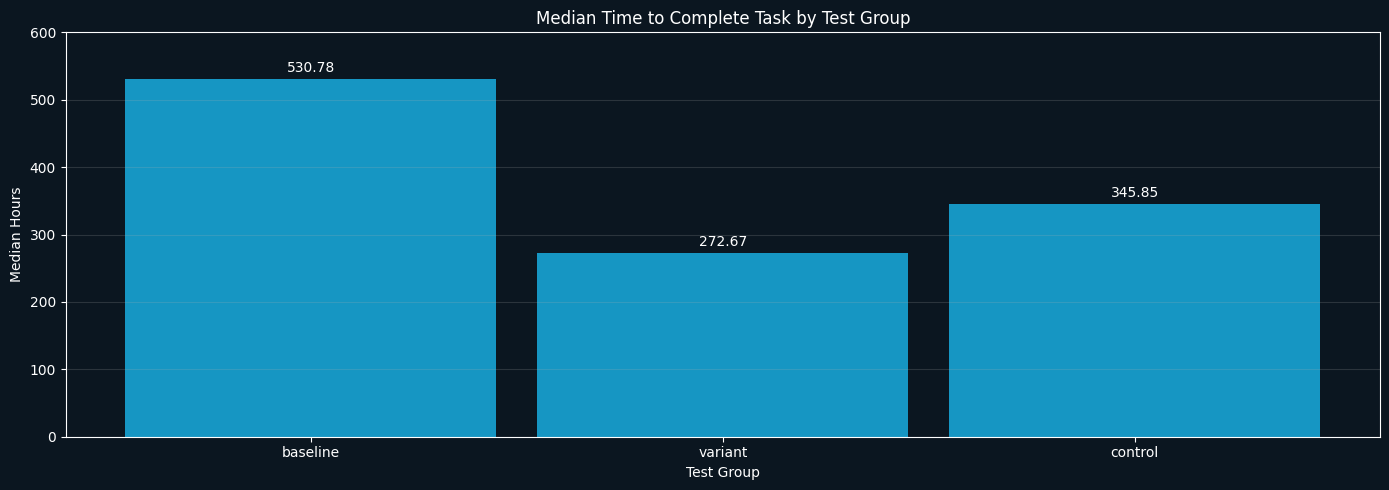

In [0]:
%python
df = spark.sql("""
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'first_collaboration_event' then event_timestamp else null end) as first_collaboration_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  signup_timestamp,
  first_collaboration_timestamp,
  date_diff(minute, signup_timestamp, first_collaboration_timestamp) as minutes_to_first_collaboration
  from merged_events
  where signup_timestamp is not null and first_collaboration_timestamp is not null
)

select
  test_group,
  round(percentile_approx(minutes_to_first_collaboration, 0.5) / 60.0,2) as median_hours
from test_group_timing
group by test_group
""").toPandas()

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df['test_group'], df['median_hours'], width=0.9, color='#1696c3')

ax.set_xlabel('Test Group', color='white')
ax.set_ylabel('Median Hours', color='white')
ax.set_title('Median Time to Complete Task by Test Group', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_ylim(0, df['median_hours'].max() + 50)
ax.set_yticks(range(0, 601, 100))

for i, v in enumerate(df['median_hours']):
    ax.text(i, v + 10, f'{v:.2f}', ha='center', color='white')

plt.tight_layout()
plt.show()

#####p75 Onboarding Length

In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  onboarding_started_timestamp,
  onboarding_completed_timestamp,
  date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) as minutes_to_complete_onboarding
  from merged_events
  where onboarding_started_timestamp is not null and onboarding_completed_timestamp is not null
)

select
  test_group,
  round(percentile_approx(minutes_to_complete_onboarding, 0.75) / 60.0,2) as p75_hours
from test_group_timing
group by test_group

test_group,p75_hours
baseline,2.37
variant,0.23
control,0.22


In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  onboarding_started_timestamp,
  onboarding_completed_timestamp,
  case when test_group = 'baseline' then date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) else null end as baseline_onboarding_length,
  case when test_group = 'control' then date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) else null end as control_onboarding_length,
  case when test_group = 'variant' then date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) else null end as variant_onboarding_length
  from merged_events
  where onboarding_started_timestamp is not null and onboarding_completed_timestamp is not null
)

select
  round(percentile_approx(baseline_onboarding_length, 0.75) / 60.0,2) as baseline_p75_hours,
  round(percentile_approx(control_onboarding_length, 0.75) / 60.0,2) as control_p75_hours,
  round(percentile_approx(variant_onboarding_length, 0.75) / 60.0,2) as variant_p75_hours,
  round(((control_p75_hours -  variant_p75_hours) / control_p75_hours)*100.0,2) as control_to_variant,
  round(((baseline_p75_hours - control_p75_hours) / baseline_p75_hours)*100.0,2) as baseline_to_control,
  round(((baseline_p75_hours - variant_p75_hours) / baseline_p75_hours)*100.0,2) as baseline_to_variant
  
from test_group_timing

baseline_p75_hours,control_p75_hours,variant_p75_hours,control_to_variant,baseline_to_control,baseline_to_variant
2.37,0.22,0.23,-4.55,90.72,90.30


p75 Onboarding Length went from 0.22 hours in the control to 0.23 hours in the variant (-4.55% decline). This is not an extreme difference, but both control and variant had ~90% improvement over baseline. 

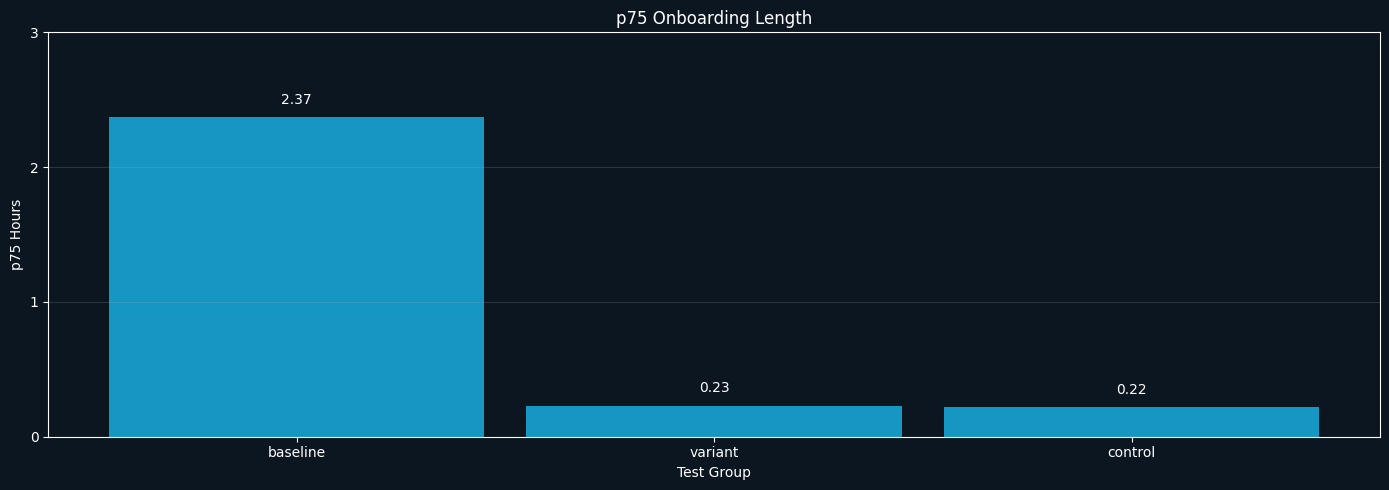

In [0]:
%python
df = spark.sql("""
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'onboarding_started' then event_timestamp else null end) as onboarding_started_timestamp,
  min(case when event_type = 'onboarding_completed' then event_timestamp else null end) as onboarding_completed_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  onboarding_started_timestamp,
  onboarding_completed_timestamp,
  date_diff(minute, onboarding_started_timestamp, onboarding_completed_timestamp) as minutes_to_complete_onboarding
  from merged_events
  where onboarding_started_timestamp is not null and onboarding_completed_timestamp is not null
)

select
  test_group,
  round(percentile_approx(minutes_to_complete_onboarding, 0.75) / 60.0,2) as p75_hours
from test_group_timing
group by test_group
""").toPandas()

df['p75_hours'] = df['p75_hours'].astype(float)

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df['test_group'], df['p75_hours'], width=0.9, color='#1696c3')

ax.set_xlabel('Test Group', color='white')
ax.set_ylabel('p75 Hours', color='white')
ax.set_title('p75 Onboarding Length', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_ylim(0, df['p75_hours'].max() + 0)
ax.set_yticks(range(0, int(df['p75_hours'].max()) + 2, 1))

for i, v in enumerate(df['p75_hours']):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', color='white')

plt.tight_layout()
plt.show()

#####p75 Time to First Invite

In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'user_invited' then event_timestamp else null end) as first_invite_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  signup_timestamp,
  first_invite_timestamp,
  date_diff(minute, signup_timestamp, first_invite_timestamp) as minutes_to_first_invite
  from merged_events
  where signup_timestamp is not null and first_invite_timestamp is not null
)

select
  test_group,
  round(percentile_approx(minutes_to_first_invite, 0.75) / 60.0,2) as p75_hours
from test_group_timing
group by test_group

test_group,p75_hours
baseline,441.80
variant,1.57
control,95.40


In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'user_invited' then event_timestamp else null end) as first_invite_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  signup_timestamp,
  first_invite_timestamp,
  case when test_group = 'baseline' then date_diff(minute, signup_timestamp, first_invite_timestamp) else null end as baseline_time_to_first_invite,
  case when test_group = 'control' then date_diff(minute, signup_timestamp, first_invite_timestamp) else null end as control_time_to_first_invite,
  case when test_group = 'variant' then date_diff(minute, signup_timestamp, first_invite_timestamp) else null end as variant_time_to_first_invite
  from merged_events
  where signup_timestamp is not null and first_invite_timestamp is not null
)

select
  round(percentile_approx(baseline_time_to_first_invite, 0.75) / 60.0,2) as baseline_p75_hours,
  round(percentile_approx(control_time_to_first_invite, 0.75) / 60.0,2) as control_p75_hours,
  round(percentile_approx(variant_time_to_first_invite, 0.75) / 60.0,2) as variant_p75_hours,
  round(((control_p75_hours -  variant_p75_hours) / control_p75_hours)*100.0,2) as control_to_variant,
  round(((baseline_p75_hours - control_p75_hours) / baseline_p75_hours)*100.0,2) as baseline_to_control,
  round(((baseline_p75_hours - variant_p75_hours) / baseline_p75_hours)*100.0,2) as baseline_to_variant
  
from test_group_timing

baseline_p75_hours,control_p75_hours,variant_p75_hours,control_to_variant,baseline_to_control,baseline_to_variant
441.80,95.40,1.57,98.35,78.41,99.64


p75 Time to First Invite went from 95.4 hours in the control to 1.57 hours in the variant (98.35% improvement).

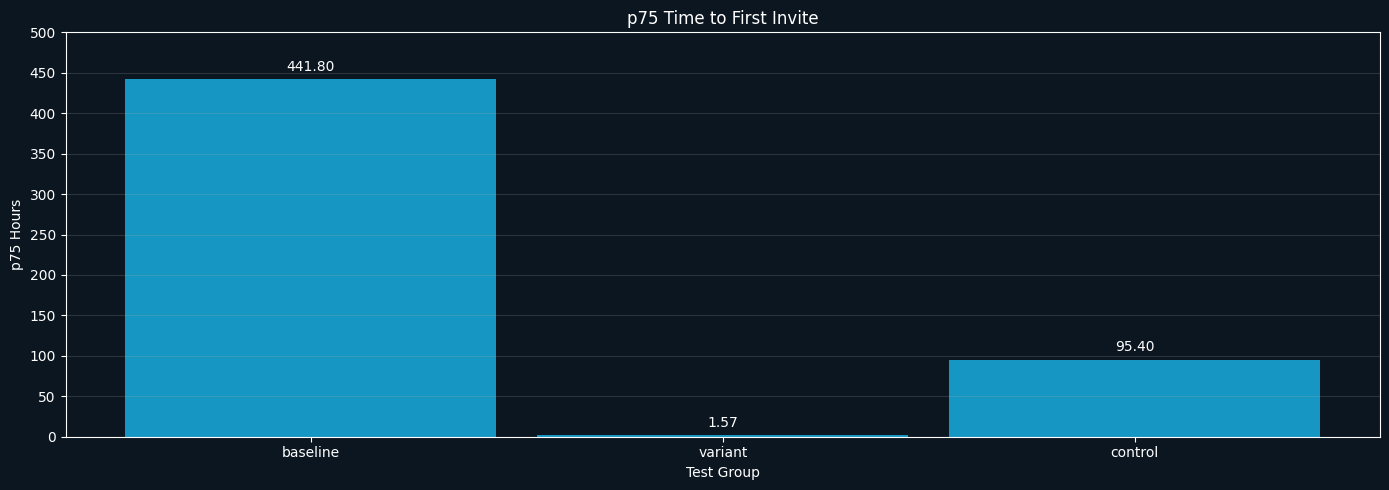

In [0]:
%python
df = spark.sql("""
with merged_events as (
  select
  org_id,
  test_group,
  min(case when event_type = 'user_signed_up' then event_timestamp else null end) as signup_timestamp,
  min(case when event_type = 'user_invited' then event_timestamp else null end) as first_invite_timestamp
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_timing as (
  select
  org_id,
  test_group,
  signup_timestamp,
  first_invite_timestamp,
  date_diff(minute, signup_timestamp, first_invite_timestamp) as minutes_to_first_invite
  from merged_events
  where signup_timestamp is not null and first_invite_timestamp is not null
)

select
  test_group,
  round(percentile_approx(minutes_to_first_invite, 0.75) / 60.0,2) as p75_hours
from test_group_timing
group by test_group
""").toPandas()

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df['test_group'], df['p75_hours'], width=0.9, color='#1696c3')

ax.set_xlabel('Test Group', color='white')
ax.set_ylabel('p75 Hours', color='white')
ax.set_title('p75 Time to First Invite', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_ylim(0, df['p75_hours'].max() + 0)
ax.set_yticks(range(0, int(df['p75_hours'].max()) + 60, 50))

for i, v in enumerate(df['p75_hours']):
    ax.text(i, v + 10, f'{v:.2f}', ha='center', color='white')

plt.tight_layout()
plt.show()

#####% Onboarding Completion

In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  max(case when event_type = 'onboarding_completed' then 1 else 0 end) as completed_onboarding
  from compare_2026_jan_feb
  group by org_id, test_group
)

select
  test_group,
  round(sum(completed_onboarding) * 100.0 / count(distinct org_id),2) as pct_completed_onboarding
from merged_events
group by test_group

test_group,pct_completed_onboarding
baseline,38.33
variant,63.33
control,40.00


In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  max(case when event_type = 'onboarding_completed' then 1 else 0 end) as completed_onboarding
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_completion as (
  select
  test_group,
  round(sum(completed_onboarding) * 100.0 / count(distinct org_id),2) as pct_onboarding_complete
  from merged_events
  where completed_onboarding is not null
  group by test_group
)

select
  max(case when test_group = 'baseline' then pct_onboarding_complete else null end) as baseline_pct_onboarding_complete,
  max(case when test_group = 'control' then pct_onboarding_complete else null end) as control_pct_onboarding_complete,
  max(case when test_group = 'variant' then pct_onboarding_complete else null end) as variant_pct_onboarding_complete,
  round(
    (max(case when test_group = 'variant' then pct_onboarding_complete else null end) - 
    max(case when test_group = 'control' then pct_onboarding_complete else null end)) / 
    max(case when test_group = 'control' then pct_onboarding_complete else null end) * 100.0, 2) as control_to_variant,
  round(
    (max(case when test_group = 'control' then pct_onboarding_complete else null end) - 
    max(case when test_group = 'baseline' then pct_onboarding_complete else null end)) / 
    max(case when test_group = 'baseline' then pct_onboarding_complete else null end) * 100.0, 2) as baseline_to_control,
  round(
    (max(case when test_group = 'variant' then pct_onboarding_complete else null end) -
    max(case when test_group = 'baseline' then pct_onboarding_complete else null end)) / 
    max(case when test_group = 'baseline' then pct_onboarding_complete else null end) * 100.0, 2) as baseline_to_variant
from test_group_completion

baseline_pct_onboarding_complete,control_pct_onboarding_complete,variant_pct_onboarding_complete,control_to_variant,baseline_to_control,baseline_to_variant
38.33,40.00,63.33,58.33,4.36,65.22


% Onboarding Complete went from 40% in the control to 63.33% in the variant (58.33% improvement).

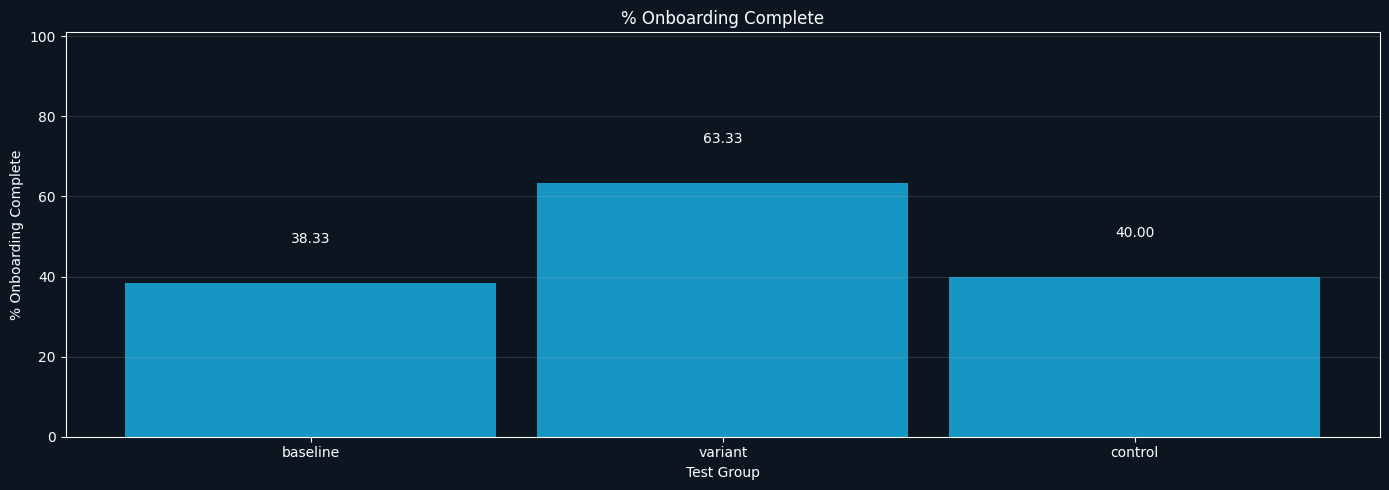

In [0]:
%python
df = spark.sql("""
with merged_events as (
  select
  org_id,
  test_group,
  max(case when event_type = 'onboarding_completed' then 1 else 0 end) as completed_onboarding
  from compare_2026_jan_feb
  group by org_id, test_group
)

select
  test_group,
  round(sum(completed_onboarding) * 100.0 / count(distinct org_id),2) as pct_completed_onboarding
from merged_events
group by test_group
""").toPandas()

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df['test_group'], df['pct_completed_onboarding'], width=0.9, color='#1696c3')

ax.set_xlabel('Test Group', color='white')
ax.set_ylabel('% Onboarding Complete', color='white')
ax.set_title('% Onboarding Complete', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_ylim(0, 101)
ax.set_yticks(range(0, 101, 20))

for i, v in enumerate(df['pct_completed_onboarding']):
    ax.text(i, v + 10, f'{v:.2f}', ha='center', color='white')

plt.tight_layout()
plt.show()

#####% Onboarding Abandon

In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  max(case when event_type = 'onboarding_abandoned' then 1 else 0 end) as abandoned_onboarding
  from compare_2026_jan_feb
  group by org_id, test_group
)

select
  test_group,
  round(sum(abandoned_onboarding) * 100.0 / count(distinct org_id),2) as pct_abandoned_onboarding
from merged_events
group by test_group

test_group,pct_abandoned_onboarding
baseline,26.67
variant,13.33
control,23.33


In [0]:
with merged_events as (
  select
  org_id,
  test_group,
  max(case when event_type = 'onboarding_abandoned' then 1 else 0 end) as abandoned_onboarding
  from compare_2026_jan_feb
  group by org_id, test_group
),

test_group_abandon as (
  select
  test_group,
  round(sum(abandoned_onboarding) * 100.0 / count(distinct org_id),2) as pct_onboarding_abandoned
  from merged_events
  where abandoned_onboarding is not null
  group by test_group
)

select
  max(case when test_group = 'baseline' then pct_onboarding_abandoned else null end) as baseline_pct_onboarding_abandoned,
  max(case when test_group = 'control' then pct_onboarding_abandoned else null end) as control_pct_onboarding_abandoned,
  max(case when test_group = 'variant' then pct_onboarding_abandoned else null end) as variant_pct_onboarding_abandoned,
  round(
    (max(case when test_group = 'control' then pct_onboarding_abandoned else null end) - 
    max(case when test_group = 'variant' then pct_onboarding_abandoned else null end)) / 
    max(case when test_group = 'control' then pct_onboarding_abandoned else null end) * 100.0, 2) as control_to_variant,
  round(
    (max(case when test_group = 'baseline' then pct_onboarding_abandoned else null end) - 
    max(case when test_group = 'control' then pct_onboarding_abandoned else null end)) / 
    max(case when test_group = 'baseline' then pct_onboarding_abandoned else null end) * 100.0, 2) as baseline_to_control,
  round(
    (max(case when test_group = 'baseline' then pct_onboarding_abandoned else null end) -
    max(case when test_group = 'variant' then pct_onboarding_abandoned else null end)) / 
    max(case when test_group = 'baseline' then pct_onboarding_abandoned else null end) * 100.0, 2) as baseline_to_variant
from test_group_abandon

baseline_pct_onboarding_abandoned,control_pct_onboarding_abandoned,variant_pct_onboarding_abandoned,control_to_variant,baseline_to_control,baseline_to_variant
26.67,23.33,13.33,42.86,12.52,50.02


% Onboarding Abandon went from 23.33% in the control to 13.33% in the variant (42.86% improvement).

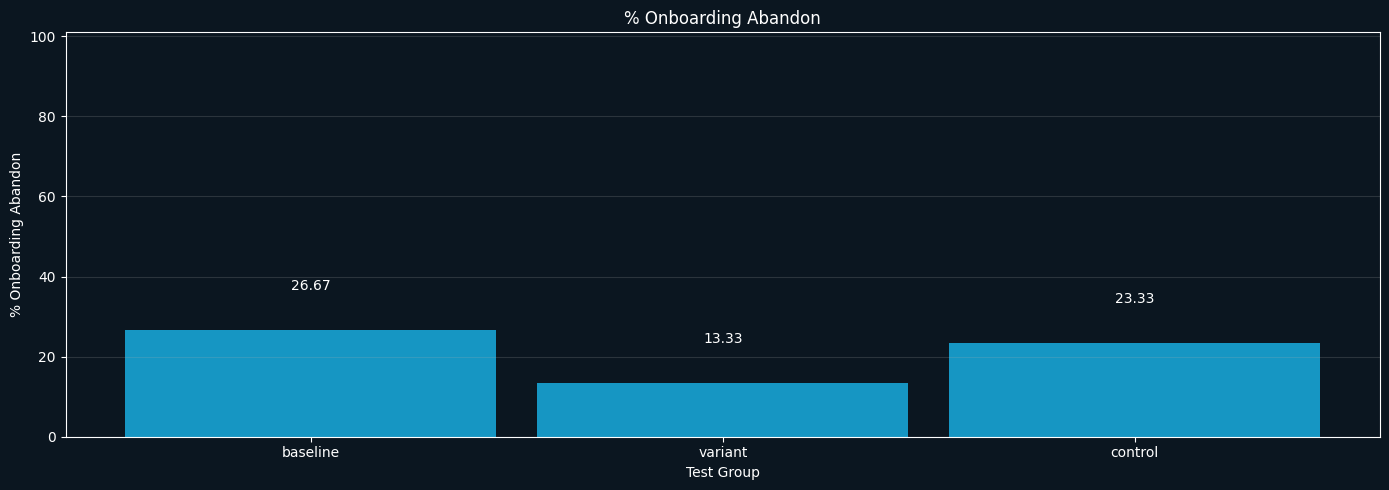

In [0]:
%python
df = spark.sql("""
with merged_events as (
  select
  org_id,
  test_group,
  max(case when event_type = 'onboarding_abandoned' then 1 else 0 end) as abandoned_onboarding
  from compare_2026_jan_feb
  group by org_id, test_group
)

select
  test_group,
  round(sum(abandoned_onboarding) * 100.0 / count(distinct org_id),2) as pct_abandoned_onboarding
from merged_events
group by test_group
""").toPandas()

fig, ax = plt.subplots(figsize=(14,5), facecolor='#0b1620')
ax.set_facecolor('#0b1620')

ax.bar(df['test_group'], df['pct_abandoned_onboarding'], width=0.9, color='#1696c3')

ax.set_xlabel('Test Group', color='white')
ax.set_ylabel('% Onboarding Abandon', color='white')
ax.set_title('% Onboarding Abandon', color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

ax.grid(axis='y', alpha=0.2)

ax.set_ylim(0, 101)
ax.set_yticks(range(0, 101, 20))

for i, v in enumerate(df['pct_abandoned_onboarding']):
    ax.text(i, v + 10, f'{v:.2f}', ha='center', color='white')

plt.tight_layout()
plt.show()

#####Section Review

The Variant group showed a 21.16% improvement over the Control group in our Primary Metric, Median Time to First Collaboration (Hours), over-achieving on the target of 10%. It also improved well in 2 of our 3 secondary metrics, only showing a very minor decline in one:

- p75 Onboarding Length (Hours): -4.55% decline
- p75 Time to First Invite (Hours): 98.35% improvement
- % Onboarding Completion: 58.33% improvement

Our guardrail metric of % Onboarding Abandon also showed a 42.86% improvement.

Our recommendation is to push the Variant test live for all new accounts going forward.